# Flood Mapping with Sentinel-1

This notebook converts the Sentinel Hub
[Flood Mapping With Sentinel-1](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/flood_mapping/)
evalscript by **Maryam Salehi** into a reusable openEO User-Defined Process (UDP).

Floods are usually accompanied by exactly the weather that blinds optical
sensors. Sentinel-1's C-band radar is its own illumination source and sees
through cloud and at night, which makes it the workhorse sensor for rapid
flood mapping. The algorithm is a **bi-temporal change detection**: it compares
one VV acquisition taken *before* the flood with one taken *during* it, and
renders the pair as a single RGB image.

## Overview

In this notebook we will:

1. Connect to an openEO backend that serves **calibrated** Sentinel-1 GRD backscatter
2. Load **two** single-date VV acquisitions over a flooded area — one before, one during
3. Merge them into one cube with unique band labels
4. Build the change composite `[1.5 × VV_before, 1.5 × VV_during, 1.5 × VV_during]`
5. Verify on a small window that the backend's units are the ones the algorithm assumes,
   and that the composite reproduces the evalscript arithmetic exactly
6. Run the full scene and visualise it
7. Derive the optional binary flood mask from the backscatter drop
8. Re-run the same graph across three flood events
9. Export the process graph as a parameterised UDP

## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/flood_mapping/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)

## Scientific Background

A radar pulse hitting **calm open water** is reflected away from the sensor almost
perfectly (specular reflection), so very little energy returns and the pixel is
dark. Nearly every other land surface is rough at C-band wavelengths (5.6 cm) and
scatters some energy back, so it is brighter. Standing flood water therefore
appears as a sudden **drop in backscatter** relative to the same pixel before the
event — the physical basis of essentially all operational SAR flood mapping
(Ulaby et al., 1982; Martinis et al., 2015).

Working with a *pair* of dates rather than a single threshold matters, because a
single dark pixel is ambiguous: permanent lakes, tarmac, dry sand and radar
shadow are all dark too. The change between two dates removes everything that was
already dark before the flood.

### The colour composite

The original evalscript places the two dates in different channels:

| Channel | Value |
| --- | --- |
| Red | `1.5 × VV(before)` |
| Green | `1.5 × VV(during)` |
| Blue | `1.5 × VV(during)` |

Because green and blue always carry the same value, the composite collapses to a
red↔cyan axis that encodes the *sign* of the change, with brightness encoding the
overall backscatter level:

| Colour | Interpretation |
| --- | --- |
| **Red** | bright before, dark during → **newly flooded land** |
| **Cyan** | dark before, bright during → backscatter *increased*, typically double-bounce between standing water and buildings or emergent vegetation (flooded urban areas, flooded forest) |
| **Black** | dark in both → permanent open water (rivers, lakes, sea) |
| **Grey / white** | similar in both → unchanged land; bright white is unchanged urban |

The `1.5` factor is a display gain applied to the linear backscatter so that
typical land values (roughly 0.05–0.4) fill the 0–1 output range.

### Choosing the two dates

The two acquisitions **must come from the same relative orbit and pass direction**.
Backscatter depends strongly on the local incidence angle, so comparing an
ascending pass with a descending one produces large differences over terrain that
have nothing to do with water. Sentinel-1's repeat cycle gives a pass of the same
relative orbit every 12 days (6 days when both S1A and S1B were operating), which
sets the practical temporal resolution of the method. Every parameter set shipped
with this notebook was checked against the CDSE STAC catalogue so that both dates
share a relative orbit.

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing,
visualization, and parameter management.

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from openeo.processes import array_create, if_

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

Load algorithm parameters from the co-located parameter file and connect to an
openEO backend.

In [61]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = "flood_mapping"

# Initialize parameter manager
param_manager = ParameterManager("flood_mapping.params.py")

# Display available options using the built-in helper
param_manager.print_options("Sentinel-1 flood mapping algorithm")

Available parameter sets for Sentinel-1 flood mapping algorithm:
  1. aq_qala_iran_2019: Aq Qala, Golestan, Iran (March 2019 flood)
  2. valencia_spain_2024: Valencia, Spain (October 2024 DANA flood)
  3. uruguaiana_brazil_2019: Uruguaiana, Rio Grande do Sul, Brazil (January 2019 flood)

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [62]:
# This algorithm requires CALIBRATED LINEAR BACKSCATTER. The Copernicus Data
# Space Ecosystem serves Sentinel-1 GRD as a calibrated, ortho-corrected product
# whose bands are linear backscatter (float, unit 1) — the convention the
# original evalscript assumes for its 1.5 gain and its 0.05 threshold.
#
# Do NOT switch this to "ds_development": that backend serves raw Level-1 GRD
# digital numbers (uint16, hundreds to thousands) and does not implement
# `sar_backscatter`, so there is no way to calibrate them there. The composite
# would saturate to a uniformly white image. The guard a few cells below catches
# this, but the fix is the endpoint, not the guard.
_endpoint = "copernicus_dataspace"
_primary_set = "valencia_spain_2024"

connection, current_params = param_manager.quick_connect(
    param_set=_primary_set,
    endpoint=_endpoint,
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: valencia_spain_2024
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Valencia, Spain (October 2024 DANA flood)
🔄 Parameters mapped for endpoint copernicus_dataspace:
  bands: ['vv'] -> ['VV']
  collection: sentinel-1-grd -> SENTINEL1_GRD


## Load the Two Acquisitions

The algorithm needs two single-date images, so we issue **two** `load_collection`
calls that differ only in their temporal extent. `bounding_box`, `time_before` and
`time_during` are passed as **`Parameter` objects** so the exported process graph
keeps its `{"from_parameter": ...}` references and stays reusable as a UDP.

Each temporal window is one day wide and therefore normally contains a single
pass. It is reduced with `mean`, which is an identity for one acquisition but
correctly mosaics the case where the area of interest straddles two consecutive
frames of the same pass (`mean` ignores no-data by default).

In [63]:
bbox = current_params["bounding_box"]
bands_dim = current_params["bands_dimension"]
time_dim = current_params["time_dimension"]

# Resolve the canonical band id to this backend's native name ("VV" on CDSE,
# "vv" on the Development Seed backend) instead of guessing from metadata.
vv_band = param_manager.band_name_map(current_params)["vv"]


def load_vv(temporal_extent):
    """Load one VV acquisition and collapse its one-day window to a single slice."""
    return connection.load_collection(
        current_params["collection"].default,
        temporal_extent=temporal_extent,
        spatial_extent=bbox,
        bands=current_params["bands"].default,
    ).reduce_dimension(dimension=time_dim, reducer="mean")


vv_before_cube = load_vv(current_params["time_before"])
vv_during_cube = load_vv(current_params["time_during"])

print(f"Native VV band on this backend: {vv_band}")
print(f"Before flood: {current_params['time_before'].default}")
print(f"During flood: {current_params['time_during'].default}")
print("✅ Sentinel-1 data loaded successfully!")

Native VV band on this backend: VV
Before flood: ['2024-10-19', '2024-10-20']
During flood: ['2024-10-31', '2024-11-01']
✅ Sentinel-1 data loaded successfully!


## Merge the Pair into One Cube

The per-pixel logic needs both dates available at once, but both cubes carry a
band called `VV`, which would collide on merge. We therefore drop each cube to a
bandless cube with `.band(...)` and re-attach a **uniquely labelled** band
dimension with `add_dimension` before merging. (`rename_labels` would be the more
direct route but is not available on CDSE.)

The original evalscript solved the same problem with `mosaicking: "ORBIT"` plus a
`preProcessScenes` filter, reading the two dates as `samples[0]` (most recent, the
flood image) and `samples[1]` (the earlier, pre-flood image).

In [64]:
# band() drops the bands dimension; add_dimension re-adds it with our label.
vv_before = vv_before_cube.band(vv_band).add_dimension(
    name=bands_dim, label="vv_before", type="bands"
)
vv_during = vv_during_cube.band(vv_band).add_dimension(
    name=bands_dim, label="vv_during", type="bands"
)

flood_pair = vv_before.merge_cubes(vv_during)

# The callbacks below read the bands positionally, so pin the order down.
pair_bands = flood_pair.metadata.band_names
print("Fused band order:", pair_bands)
assert pair_bands == ["vv_before", "vv_during"], f"unexpected band order: {pair_bands}"

Fused band order: ['vv_before', 'vv_during']


## Build the Change Composite

A single `apply_dimension` over the bands dimension runs the original
`evaluatePixel` logic: `calcFM()` applies the 1.5 gain, and the return value
`[outbe, outdu, outdu]` puts the before-flood image in red and the flood image in
green and blue.

`linear_scale_range` then maps the 0–1 result onto the 0–255 range an 8-bit
renderer expects, clipping anything outside it — the same implicit behaviour as
Sentinel Hub's default rendering of a 3-band output.

In [65]:
# Display gain from the original's calcFM(): return [1.5 * sample.VV]
BACKSCATTER_GAIN = 1.5


def flood_composite(data):
    """[1.5*VV_before, 1.5*VV_during, 1.5*VV_during] — the original evaluatePixel."""
    before = BACKSCATTER_GAIN * data[0]
    during = BACKSCATTER_GAIN * data[1]
    return array_create([before, during, during])


flood_rgb = flood_pair.apply_dimension(dimension=bands_dim, process=flood_composite)

flood_rgb = flood_rgb.linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
)

# GTiff keeps the values inspectable for the numerical validation below; swapping
# in save_result("PNG") yields a composite ready for synchronous web-map tiling.
flood_result = flood_rgb.save_result("GTiff")

## Check the Backend's Backscatter Convention

**This check runs before the full-scene request on purpose.** The `1.5` gain and
the `0.05` threshold are only meaningful if the backend serves *calibrated linear
backscatter* in roughly 0–1. Two other conventions are common in the wild:

- **raw Level-1 digital numbers** (integers in the hundreds or thousands), and
- **decibels** (negative values, typically −25 to 0).

Under either of them `1.5 × VV` lands far outside 0–1, `linear_scale_range`
clips every pixel to 255, and the composite comes out **uniformly white** — a
silent failure that looks like a broken plot rather than a wrong input. So we
pull a small window first, assert the values really are linear backscatter, and
only then verify the arithmetic and run the full scene.

The composite should be exactly `round(clip(1.5 × VV, 0, 1) × 255)` per channel,
so we download both the raw pair and the composite over the *same* small window —
identical bounding box, hence identical pixel grid — and compare element by
element.

In [66]:
_bb = current_params["bounding_box"].default
_cx = (_bb["west"] + _bb["east"]) / 2
_cy = (_bb["south"] + _bb["north"]) / 2
check_bbox = {
    "west": round(_cx - 0.02, 4),
    "east": round(_cx + 0.02, 4),
    "south": round(_cy - 0.02, 4),
    "north": round(_cy + 0.02, 4),
}


def load_vv_at(temporal_extent, extent, label):
    """Same load as above but over an explicit extent, labelled for merging."""
    cube = connection.load_collection(
        current_params["collection"].default,
        temporal_extent=temporal_extent,
        spatial_extent=extent,
        bands=current_params["bands"].default,
    ).reduce_dimension(dimension=time_dim, reducer="mean")
    return cube.band(vv_band).add_dimension(name=bands_dim, label=label, type="bands")


check_pair = load_vv_at(
    current_params["time_before"].default, check_bbox, "vv_before"
).merge_cubes(
    load_vv_at(current_params["time_during"].default, check_bbox, "vv_during")
)

# 1. the raw linear backscatter pair
check_pair.save_result("GTiff").download("flood_mapping_check_raw.tif")

# 2. the composite over the identical window
check_pair.apply_dimension(
    dimension=bands_dim, process=flood_composite
).linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
).save_result("GTiff").download("flood_mapping_check_rgb.tif")

print("✅ Downloaded validation window:", check_bbox)

✅ Downloaded validation window: {'west': -0.395, 'east': -0.355, 'south': 39.265, 'north': 39.305}


In [67]:
raw = rioxarray.open_rasterio("flood_mapping_check_raw.tif").values.astype("float64")
comp_da = rioxarray.open_rasterio("flood_mapping_check_rgb.tif")
comp = comp_da.values.astype("float64")
comp[comp == comp_da.rio.nodata] = np.nan

vv_b, vv_d = raw[0], raw[1]
valid = np.isfinite(vv_b) & np.isfinite(vv_d) & np.isfinite(comp[0])

print(f"VV before — min {np.nanmin(vv_b):.4f}, median {np.nanmedian(vv_b):.4f}, max {np.nanmax(vv_b):.3f}")
print(f"VV during — min {np.nanmin(vv_d):.4f}, median {np.nanmedian(vv_d):.4f}, max {np.nanmax(vv_d):.3f}")

# --- Calibration guard -------------------------------------------------------
# Linear backscatter is non-negative, and over land the bulk of it sits well
# below 1; only strong specular/double-bounce targets exceed it, so we test a
# high percentile rather than the max. This assertion is what stands between a
# mis-calibrated backend and a silently all-white composite.
_p99 = float(np.nanpercentile(vv_b[valid], 99))
_median = float(np.nanmedian(vv_b[valid]))

assert np.nanmin(vv_b[valid]) >= 0, (
    "VV contains negative values, so this backend is serving decibels rather "
    "than linear backscatter. The 1.5 gain and the 0.05 threshold assume linear "
    "backscatter; convert with 10**(dB/10) or use a backend that serves linear."
)
assert _p99 <= 2.0, (
    f"VV 99th percentile is {_p99:.1f} (median {_median:.1f}), far outside the "
    "0-1 range of calibrated linear backscatter — this backend is serving raw "
    "Level-1 digital numbers. The algorithm's 1.5 gain and 0.05 threshold are "
    "meaningless for uncalibrated DN and the composite would saturate to white. "
    "Use a backend that serves calibrated backscatter (CDSE's SENTINEL1_GRD "
    "does), or apply `sar_backscatter` first where the backend supports it."
)
print(f"✅ Values are calibrated linear backscatter (99th pct {_p99:.3f})")

# Exact arithmetic: each channel must reproduce the evalscript formula.
expected = {
    0: np.clip(BACKSCATTER_GAIN * vv_b, 0, 1) * 255,
    1: np.clip(BACKSCATTER_GAIN * vv_d, 0, 1) * 255,
    2: np.clip(BACKSCATTER_GAIN * vv_d, 0, 1) * 255,
}
for channel, want in expected.items():
    diff = np.abs(comp[channel][valid] - want[valid])
    # The backend writes the scaled result as an integer raster and computes in
    # float32, so a sub-DN discrepancy is expected; anything approaching a full
    # digital number out of 255 would mean the formula itself differs.
    assert diff.max() <= 1.0, f"channel {channel} max deviation {diff.max()} DN"
    print(
        f"channel {channel}: max deviation from 1.5×VV×255 = {diff.max():.4f} DN "
        f"(mean {diff.mean():.4f} DN)"
    )

assert np.array_equal(comp[1][valid], comp[2][valid]), "green and blue must be identical"
print("✅ Composite reproduces the evalscript formula exactly (within integer rounding)")

VV before — min 0.0009, median 0.0914, max 108.996
VV during — min 0.0000, median 0.0577, max 115.638
✅ Values are calibrated linear backscatter (99th pct 0.598)
channel 0: max deviation from 1.5×VV×255 = 1.0000 DN (mean 0.4944 DN)
channel 1: max deviation from 1.5×VV×255 = 1.0000 DN (mean 0.4943 DN)
channel 2: max deviation from 1.5×VV×255 = 1.0000 DN (mean 0.4943 DN)
✅ Composite reproduces the evalscript formula exactly (within integer rounding)


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


## Execute and Download

In [68]:
_location_slug = (
    current_params["location_name"].split(",")[0].strip().lower().replace(" ", "_")
)
rgb_filename = f"{_algorithm_id}_{_location_slug}.tif"

# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialise them here. `flood_result` itself keeps them for the UDP export.
param_manager.resolve(flood_result, current_params).download(rgb_filename)
print(f"✅ Downloaded {rgb_filename}")

✅ Downloaded flood_mapping_valencia.tif


## Visualize the Result

The red channel *is* the scaled before-flood image and the green channel the
flood image, so both single-date views can be shown alongside the composite
without issuing another request.

In [69]:
def read_rgb(path):
    """Read a 3-band composite as float RGB in 0-1, with no-data mapped to NaN."""
    da = rioxarray.open_rasterio(path)
    arr = da.values.astype("float32")
    if da.rio.nodata is not None:
        arr[arr == da.rio.nodata] = np.nan
    return np.transpose(arr, (1, 2, 0)) / 255.0


rgb = read_rgb(rgb_filename)
print(f"composite shape (rows, cols, bands): {rgb.shape}")

composite shape (rows, cols, bands): (3061, 2245, 3)


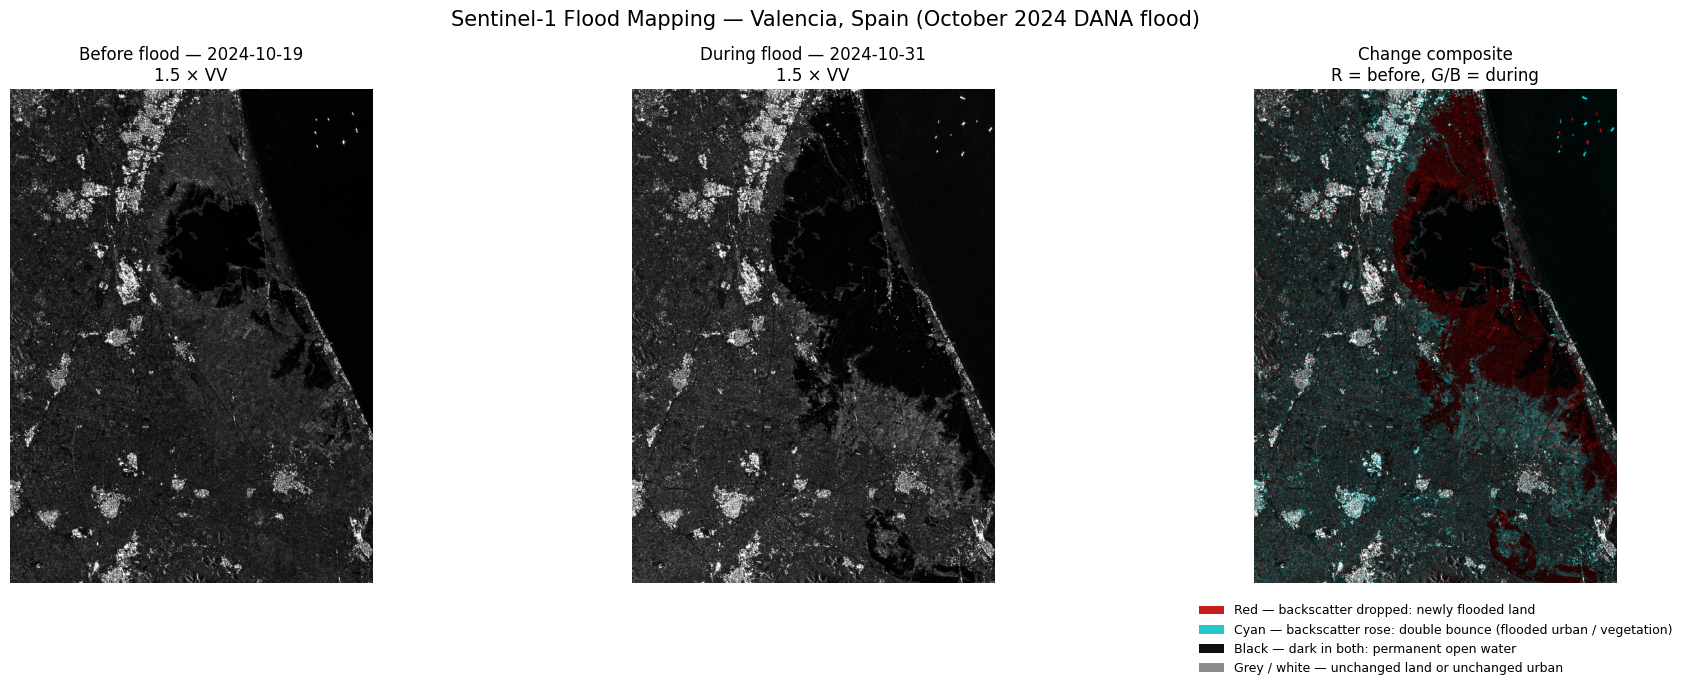

In [70]:
before_img, during_img = rgb[..., 0], rgb[..., 1]

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
axes[0].imshow(before_img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(
    f"Before flood — {current_params['time_before'].default[0]}\n1.5 × VV"
)
axes[1].imshow(during_img, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(
    f"During flood — {current_params['time_during'].default[0]}\n1.5 × VV"
)
axes[2].imshow(np.nan_to_num(rgb))
axes[2].set_title("Change composite\nR = before, G/B = during")

for ax in axes:
    ax.axis("off")

legend = [
    Patch(facecolor="#c81e1e", label="Red — backscatter dropped: newly flooded land"),
    Patch(facecolor="#25c8c8", label="Cyan — backscatter rose: double bounce (flooded urban / vegetation)"),
    Patch(facecolor="#101010", label="Black — dark in both: permanent open water"),
    Patch(facecolor="#8c8c8c", label="Grey / white — unchanged land or unchanged urban"),
]
axes[2].legend(
    handles=legend,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    fontsize=9,
    frameon=False,
)

fig.suptitle(
    f"Sentinel-1 Flood Mapping — {current_params['location_name']}", fontsize=15
)
plt.tight_layout()
plt.show()

## Optional: Binary Flood Mask

The original evalscript carries a commented-out second output that turns the
composite into a binary mask by thresholding the difference between the two
scaled images:

```javascript
// var dout = outbe - outdu;
// return [dout > 0.05 ? 1 : 0]
```

Because `outbe` and `outdu` are the *already scaled* values, the threshold applies
to `1.5 × (VV_before − VV_during)`. The script documents `0.05` (the default,
used here) and `0.08` as a less sensitive alternative. The threshold lives in the
parameter file so it can be tuned per site.

In [71]:
FLOOD_THRESHOLD = current_params["flood_threshold"].default


def flood_mask(data):
    """The evalscript's mask branch: (1.5*VV_before - 1.5*VV_during) > threshold."""
    drop = BACKSCATTER_GAIN * data[0] - BACKSCATTER_GAIN * data[1]
    return array_create([if_(drop > FLOOD_THRESHOLD, 1.0, 0.0)])


flood_mask_result = flood_pair.apply_dimension(
    dimension=bands_dim, process=flood_mask
).save_result("GTiff")

mask_filename = f"{_algorithm_id}_{_location_slug}_mask.tif"
param_manager.resolve(flood_mask_result, current_params).download(mask_filename)
print(f"✅ Downloaded {mask_filename} (threshold = {FLOOD_THRESHOLD})")

✅ Downloaded flood_mapping_valencia_mask.tif (threshold = 0.05)


pixel size: 10.0 x 10.0 m (EPSG:32630)
flagged as flooded: 22.0% of valid pixels ≈ 151 km²


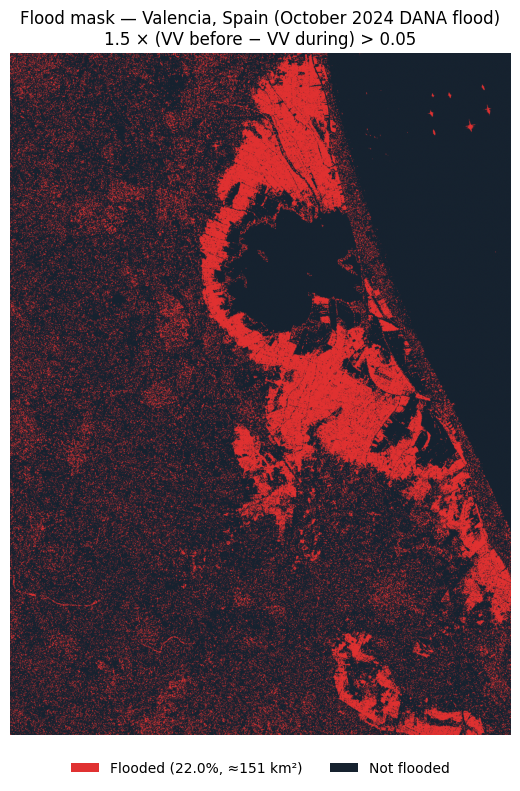

In [72]:
mask_da = rioxarray.open_rasterio(mask_filename)
mask = mask_da.values[0].astype("float32")
mask_valid = np.isfinite(mask)

res_x, res_y = mask_da.rio.resolution()

# Backends differ in output CRS: CDSE returns a projected UTM grid (metres),
# while others return EPSG:4326 (degrees). Converting degrees with the local
# scale factor keeps the area figure honest instead of reporting 0 km².
if mask_da.rio.crs is not None and mask_da.rio.crs.is_geographic:
    _lat = float(np.mean(mask_da.y.values))
    _m_per_deg_lat = 111_132.0
    _m_per_deg_lon = 111_320.0 * np.cos(np.radians(_lat))
    px_x, px_y = abs(res_x) * _m_per_deg_lon, abs(res_y) * _m_per_deg_lat
else:
    px_x, px_y = abs(res_x), abs(res_y)

pixel_area_km2 = px_x * px_y / 1e6
flooded_km2 = float(np.nansum(mask[mask_valid])) * pixel_area_km2
flooded_fraction = float(np.mean(mask[mask_valid]))

print(f"pixel size: {px_x:.1f} x {px_y:.1f} m ({mask_da.rio.crs})")
print(f"flagged as flooded: {flooded_fraction:.1%} of valid pixels ≈ {flooded_km2:.0f} km²")

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(np.nan_to_num(mask), cmap=ListedColormap(["#16222f", "#e03131"]), vmin=0, vmax=1)
ax.set_title(
    f"Flood mask — {current_params['location_name']}\n"
    f"1.5 × (VV before − VV during) > {FLOOD_THRESHOLD}",
    fontsize=12,
)
ax.axis("off")
ax.legend(
    handles=[
        Patch(facecolor="#e03131", label=f"Flooded ({flooded_fraction:.1%}, ≈{flooded_km2:.0f} km²)"),
        Patch(facecolor="#16222f", label="Not flooded"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
)
plt.tight_layout()
plt.show()

## Validation Across Multiple Flood Events

A conversion that only works on the scene it was tuned on is not a conversion. We
re-run the identical graph on the two other parameter sets, which cover very
different landscapes:

- **Valencia, Spain (29 October 2024 DANA)** — a Mediterranean coastal plain with a
  large permanent lagoon (the Albufera), dense towns and irrigated agriculture.
- **Uruguaiana, Brazil (January 2019)** — a broad river floodplain under
  large-field agriculture, a much subtler case.

In [73]:
def build_flood_composite(params):
    """The same steps as above, packaged so another site runs in one call."""
    b_dim, t_dim = params["bands_dimension"], params["time_dimension"]
    native_vv = param_manager.band_name_map(params)["vv"]

    def _one(extent, label):
        cube = connection.load_collection(
            params["collection"].default,
            temporal_extent=extent,
            spatial_extent=params["bounding_box"],
            bands=params["bands"].default,
        ).reduce_dimension(dimension=t_dim, reducer="mean")
        return cube.band(native_vv).add_dimension(name=b_dim, label=label, type="bands")

    pair = _one(params["time_before"], "vv_before").merge_cubes(
        _one(params["time_during"], "vv_during")
    )
    composite = pair.apply_dimension(dimension=b_dim, process=flood_composite)
    return composite.linear_scale_range(
        input_min=0, input_max=1, output_min=0, output_max=255
    ).save_result("GTiff")


validation_sets = ["valencia_spain_2024", "uruguaiana_brazil_2019"]
validation_outputs = {}

for set_name in validation_sets:
    _, val_params = param_manager.quick_connect(
        param_set=set_name, endpoint=_endpoint, silent=True
    )
    val_file = f"{_algorithm_id}_{set_name}.tif"
    param_manager.resolve(build_flood_composite(val_params), val_params).download(val_file)
    validation_outputs[set_name] = (val_file, val_params)
    print(f"✅ {set_name}: {val_file}")

# Restore the primary parameter set for the export section below.
param_manager.use_parameter_set(_primary_set)

Authenticated using refresh token.
✅ valencia_spain_2024: flood_mapping_valencia_spain_2024.tif
Authenticated using refresh token.
✅ uruguaiana_brazil_2019: flood_mapping_uruguaiana_brazil_2019.tif


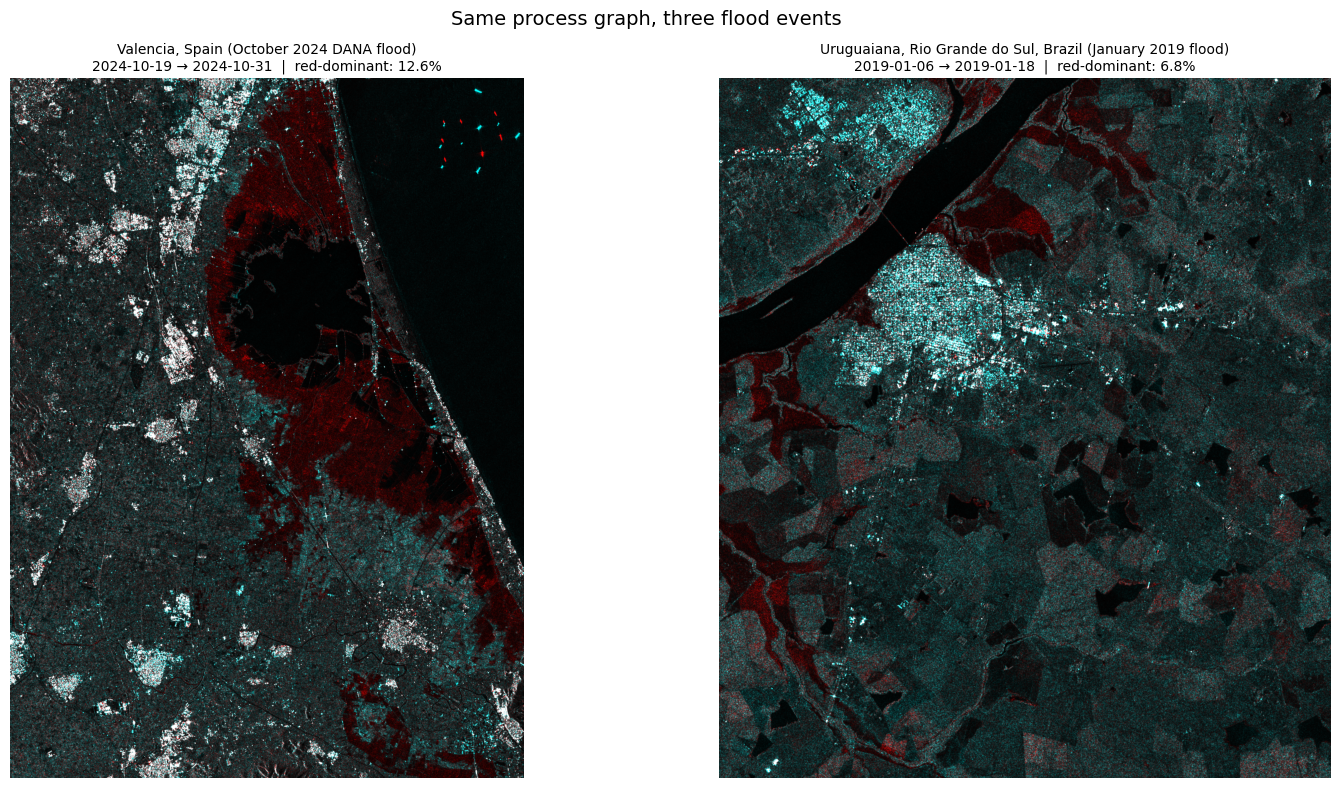

In [74]:
fig, axes = plt.subplots(1, len(validation_outputs), figsize=(16, 8))

for ax, set_name in zip(np.atleast_1d(axes), validation_sets, strict=True):
    val_file, val_params = validation_outputs[set_name]
    val_rgb = read_rgb(val_file)
    # Fraction of pixels where the before-image is clearly brighter than the
    # flood image — the red-dominant, i.e. newly inundated, part of the scene.
    red_dominant = float(np.nanmean((val_rgb[..., 0] - val_rgb[..., 1]) > 0.1))
    ax.imshow(np.nan_to_num(val_rgb))
    ax.set_title(
        f"{val_params['location_name']}\n"
        f"{val_params['time_before'].default[0]} → {val_params['time_during'].default[0]}  |  "
        f"red-dominant: {red_dominant:.1%}",
        fontsize=10,
    )
    ax.axis("off")

fig.suptitle("Same process graph, three flood events", fontsize=14)
plt.tight_layout()
plt.show()

### What the validation shows

**Aq Qala, Iran (the original's own example, same two dates).** The Gorgan
floodplain reads as a broad red sheet where the March 2019 inundation was mapped,
the river channel and the reservoirs stay black, and the town of Aq Qala is
cyan — the double-bounce brightening expected when water stands between
buildings. That is the red / black / cyan signature the original script page
describes for this scene.

**Valencia, Spain.** The Albufera lagoon is black (permanent water) and is ringed
by a thick red band over the flooded Horta Sud plain and the rice fields; the sea
is black, and the coastal towns stay bright. This is the clearest of the three
cases.

**Uruguaiana, Brazil.** Much subtler: red follows the tributary valleys and the
low-lying margins of the Uruguay river, and the city is cyan. Scattered red also
appears on individual agricultural fields — a genuine false-positive mode
discussed below, not a defect of the conversion.

### Edge cases

- **No-data.** Pixels outside a frame's footprint come back as the raster's
  no-data value and are carried through the arithmetic without failing; they are
  masked to NaN before display. Neither `apply_dimension` nor the threshold
  produces a hard error on them.
- **Out-of-range values.** Very strong scatterers push `1.5 × VV` above 1.
  `linear_scale_range` clips them to 255 rather than wrapping, matching Sentinel
  Hub's renderer.
- **Extreme darkness.** Calm water can return backscatter near zero; the formula
  is a scale and a subtraction, so there is no division and no risk of a
  zero-denominator or infinite value anywhere in the graph.
- **Temporal gaps.** If a one-day window contains no acquisition, the backend
  returns an empty temporal dimension and `load_collection` fails loudly rather
  than silently producing an empty image — which is the desired behaviour, since
  a missing date invalidates the comparison.

## Limitations and Differences from the Original

- **Scene selection.** The original used `mosaicking: "ORBIT"` with a
  `preProcessScenes` filter that kept exactly two orbit dates. openEO has no
  equivalent hook, so the same effect is achieved with two `load_collection`
  calls over one-day windows plus a `mean` reduction. The practical consequence
  is identical; the responsibility for picking two same-relative-orbit dates
  moves to whoever fills in the parameters.
- **Same-orbit pairing is not enforced.** The graph cannot check that
  `time_before` and `time_during` belong to the same relative orbit. Pairing an
  ascending with a descending pass will produce large, entirely spurious red and
  cyan areas over any terrain with relief. The shipped parameter sets are all
  orbit-consistent; the Uruguaiana set moves the original's "during" date from
  14 January to 18 January for this reason.
- **Backscatter convention — the binding constraint.** The `1.5` gain and the
  `0.05` threshold assume *linear* backscatter in roughly 0–1, as served by CDSE.
  On a backend returning dB or raw digital numbers both constants are meaningless.
  In particular the **Development Seed backend (`ds_development`) cannot run this
  algorithm**: it serves raw Level-1 GRD digital numbers (uint16, median ≈ 130 in
  the Aq Qala scene) and does not implement `sar_backscatter`, so the values
  cannot be calibrated there at all. Pointing the notebook at it produces a
  uniformly white composite. The calibration guard above turns that into an
  explicit failure instead of a silently blank image.
- **Seasonal water is indistinguishable from flood water.** Rice paddies, managed
  wetlands and irrigated fields flood on a schedule and produce exactly the same
  backscatter drop. Part of the red ring around the Albufera is seasonal paddy
  flooding rather than DANA damage. Distinguishing the two needs an external
  land-cover or permanent-water layer, which is outside the original's scope.
- **Other false-positive modes.** Smooth dry surfaces (fresh tarmac, dry sand,
  recently harvested or rolled fields), radar shadow behind steep terrain and
  wind-free days over shallow water all darken a pixel without any flood. Wind
  roughening the surface of real flood water produces the opposite error, a false
  negative.
- **Flooded vegetation and urban areas are not in the mask.** They *brighten*
  (cyan in the composite) rather than darken, so the difference threshold misses
  them entirely. The composite still shows them, which is one reason the RGB — not
  the mask — is the exported product.
- **No speckle filtering.** SAR speckle produces salt-and-pepper noise in the
  binary mask; the original applies none and neither does this conversion. A
  spatial filter before thresholding would clean it up at the cost of resolution.
- **No terrain correction beyond the product's own.** The conversion inherits
  whatever ortho-rectification the backend's GRD product applies.

## Export the Process Graph

The exported UDP is the **RGB change composite**, which is what the evalscript's
active `evaluatePixel` returns. Its parameters are the three runtime knobs —
area of interest and the two dates — while the collection, the band and the
display gain stay intrinsic to the algorithm.

In [75]:
# Create a directory to export images, UDP, and OGC API records
from pathlib import Path

_repo_root = next(p for p in Path.cwd().parents if (p / "notebooks").exists())
_alg_dir = _repo_root / "algorithm_registration" / _algorithm_id
_records_dir = _alg_dir / "records"
_udp_dir = _alg_dir / "openeo_udp"

_records_dir.mkdir(parents=True, exist_ok=True)
_udp_dir.mkdir(parents=True, exist_ok=True)

In [76]:
# Export the process graph for reuse as a parameterized UDP
import json

process_graph = {
    "process_graph": flood_result.flat_graph(),
    "parameters": [
        current_params["bounding_box"].to_dict(),
        current_params["time_before"].to_dict(),
        current_params["time_during"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "Bi-temporal Sentinel-1 VV flood mapping using openEO.",
    "description": (
        "Maps flood extent by comparing Sentinel-1 GRD VV backscatter from before "
        "and during a flood. Open water reflects the radar pulse away from the "
        "sensor, so newly inundated land darkens between the two dates. The two "
        "acquisitions are rendered as an RGB composite "
        "[1.5*VV_before, 1.5*VV_during, 1.5*VV_during] in which newly flooded land "
        "appears red, permanent water black, flooded built-up areas cyan and "
        "unchanged land grey. Both dates must come from the same Sentinel-1 "
        "relative orbit and pass direction. Converted from the Sentinel Hub Flood "
        "Mapping evalscript by Maryam Salehi."
    ),
}

with open(f"{_udp_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(process_graph, f, indent=2)

print(f"Process graph exported to {_udp_dir}/{_algorithm_id}.json")
print(f"Process ID: {_algorithm_id}")

Process graph exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/flood_mapping/openeo_udp/flood_mapping.json
Process ID: flood_mapping


In [77]:
# Export metadata to register the process graph in the APEx Algorithm Catalogue
_nb_href = f"{(Path.cwd() / f'{_algorithm_id}.ipynb').relative_to(_repo_root)}"

metadata = {
    "id": _algorithm_id,
    "title": "Flood Mapping (Sentinel-1)",
    "preview_title": "Flood Mapping (Sentinel-1)",
    "description": (
        "Bi-temporal Sentinel-1 VV change detection that maps flood extent by "
        "comparing backscatter from before and during a flood, rendering newly "
        "inundated land in red, permanent water in black and flooded built-up "
        "areas in cyan."
    ),
    "keywords": [
        "Flood",
        "Flood mapping",
        "Inundation",
        "Change detection",
        "SAR",
        "Backscatter",
        "Sentinel-1",
    ],
    "themes": ["FLOODS", "DISASTER MONITORING", "INLAND WATERS", "REMOTE SENSING", "Sentinel-1 SAR"],
    "created": "2026-07-28T00:00:00Z",
    "updated": "2026-07-28T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": "CDSE openEO Federation",
    "openeo_backend_url": "https://openeofed.dataspace.copernicus.eu",
    "notebook_github_location": _nb_href,
    "collection_id": "SENTINEL1_GRD",
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/flood_mapping/",
        "authors": ["Maryam Salehi"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
        "citation": (
            "Martinis, S., Kersten, J., Twele, A. (2015). A fully automated TerraSAR-X "
            "based flood service. ISPRS Journal of Photogrammetry and Remote Sensing, 104, 203-212."
        ),
    },
}

with open(f"{_records_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Catalogue record exported to {_records_dir}/{_algorithm_id}.json")

Catalogue record exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/flood_mapping/records/flood_mapping.json


## References and Attribution

**Original Script:** [Flood Mapping With Sentinel-1](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/flood_mapping/)

**Author:** Maryam Salehi

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### Scientific references

- Ulaby, F. T., Moore, R. K., Fung, A. K. (1982). *Microwave Remote Sensing:
  Active and Passive, Vol. II.* Addison-Wesley. — the specular-reflection
  behaviour of smooth water at microwave wavelengths.
- Martinis, S., Kersten, J., Twele, A. (2015). A fully automated TerraSAR-X based
  flood service. *ISPRS Journal of Photogrammetry and Remote Sensing*, 104,
  203–212. — operational SAR flood mapping and its failure modes.
- Shen, X. et al. (2019). Near-real-time non-obstructed flood inundation mapping
  using synthetic aperture radar. *Remote Sensing of Environment*, 221, 302–315. —
  change-detection flood mapping with Sentinel-1.

### openEO Conversion

- **Conversion Date**: 28 July 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
- **Backend Tested**: CDSE (Copernicus Data Space Ecosystem)
- **License**: CC-BY-SA-4.0

## Conclusion

This notebook converts the Sentinel Hub Flood Mapping evalscript into an openEO
User-Defined Process. The implementation:

✅ **Reproduces the original composite exactly** — verified pixel by pixel against
`round(clip(1.5 × VV, 0, 1) × 255)` on a validation window.

✅ **Replaces `mosaicking: "ORBIT"` + `preProcessScenes`** with two
`load_collection` calls over one-day windows, merged via `add_dimension` and
`merge_cubes` into a single two-band cube.

✅ **Generalises across events** — the same graph was run unchanged on three
floods on three continents, in landscapes ranging from an arid alluvial plain to
a Mediterranean coastal wetland.

✅ **Ships both outputs** — the RGB composite as the exported UDP, and the
evalscript's commented-out binary mask as a documented variant.

### Key conversion notes

- `bounding_box`, `time_before` and `time_during` are the UDP parameters; the
  collection, the VV band and the 1.5 display gain are intrinsic to the algorithm.
- The two dates **must** share a relative orbit and pass direction; the graph
  cannot enforce this, so it is documented in the parameter file and checked for
  every shipped parameter set.
- Targets CDSE, which serves Sentinel-1 GRD as calibrated linear backscatter —
  the convention the original's constants assume.

### Possible extensions

- Mask the result with a permanent-water layer to isolate flood water from
  seasonal and permanent water bodies.
- Apply a speckle filter before thresholding to clean up the binary mask.
- Chain several "during" dates to animate the rise and recession of a flood.